# Alternative 2: potential hydrological connectivity (Mole Creek)

This notebook tests a simple, transparent combination of three kinds of evidence:

1. DEM flow accumulation as a relative indicator of potential surface-water concentration.
2. LIST `Watercourse` lines as independent evidence of mapped surface drainage.
3. Karst Atlas `KPROXCATCH` as evidence that a cell belongs to a mapped proximal catchment associated with karst.

The result is interpreted as **relative potential for surface water to be concentrated and connected to mapped karst catchments**. Flow accumulation is not discharge or groundwater flow, and a mapped Watercourse is not a measure of flow volume. `KPROXCATCH` letters are used only as presence/absence; they are not converted to scores. `KDISTCATCH` is not used.

The notebook reads the existing DEM and flow-accumulation raster. It creates new, distinctly named alternative rasters in `Output_data`; it does not overwrite the existing hydrological model outputs.


## 1. Inputs, grid, and output names

The workflow uses the project's `Input_data/Hydline` municipality files and the Stage 2 karst GeoPackage. No merged Watercourse GeoPackage is stored in `Output_data`, so this self-contained notebook reads the 29 source files and merges only records where `HYDLNTY1` is exactly `Watercourse`. Other Hydline categories are excluded.

The existing flow-accumulation raster is the grid template. The notebook checks that it matches the existing 25 m Mole Creek DEM. All four alternative rasters use this exact grid and use 255 as NoData outside valid DEM cells.


In [1]:
from pathlib import Path
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.features import rasterize

# Resolve the project root whether Jupyter starts in the repository or notebooks folder.
working_dir = Path.cwd()
project_root = working_dir.parent if working_dir.name == "notebooks" else working_dir

# Use an inherited variable first; otherwise read only AT3_DATA_DIR from the project .env.
data_dir_value = os.environ.get("AT3_DATA_DIR")
if not data_dir_value:
    env_file = project_root / ".env"
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8-sig").splitlines():
            entry = line.strip()
            if entry.startswith("AT3_DATA_DIR="):
                data_dir_value = entry.split("=", 1)[1].strip().strip("\"").strip("'")
                break

data_path = Path(data_dir_value).expanduser() if data_dir_value else project_root / "data"
if not data_path.is_absolute():
    data_path = (project_root / data_path).resolve()

input_path = data_path / "Input_data"
output_path = data_path / "Output_data"
dem_path = output_path / "dem_mc_EPSG7855.tif"
flow_accumulation_path = output_path / "flow_accum_mc_EPSG7855.tif"
karst_atlas_path = output_path / "karst_mc_susceptibility_EPSG7855.gpkg"
hydline_root = input_path / "Hydline"

# New names keep these alternative results separate from existing Stage 3 rasters.
output_paths = {
    "dem_drainage_class": output_path / "dem_drainage_class_mc_EPSG7855_alt2.tif",
    "watercourse_presence": output_path / "watercourse_presence_mc_EPSG7855_alt2.tif",
    "kproxcatch_presence": output_path / "kproxcatch_presence_mc_EPSG7855_alt2.tif",
    "potential_connectivity": output_path / "potential_hydrological_connectivity_mc_EPSG7855_alt2.tif",
}


## 2. Relative DEM drainage classes

The flow-accumulation values are divided into three equal-frequency groups using the 33? and 66? percentiles of valid cells (tertiles). This gives relative Low, Moderate, and High classes for this study area, rather than applying a fixed channel threshold. Because the input is integer cell counts, ties at the quantile breaks can make class sizes unequal; the measured breaks and resulting counts are printed below.

For the current raster, the expected breaks are 3 and 10 upstream cells. These are quantile results for this DEM, not universal hydrological thresholds.


In [2]:
with rasterio.open(dem_path) as dem_src:
    dem_masked = dem_src.read(1, masked=True)
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs
    dem_shape = (dem_src.height, dem_src.width)

with rasterio.open(flow_accumulation_path) as flow_src:
    flow_masked = flow_src.read(1, masked=True)
    flow_transform = flow_src.transform
    flow_crs = flow_src.crs
    flow_profile = flow_src.profile.copy()

if dem_shape != flow_masked.shape or dem_transform != flow_transform or dem_crs != flow_crs:
    raise ValueError("The existing DEM and flow-accumulation raster are not aligned")

valid_cells = ~(
    np.ma.getmaskarray(dem_masked) | np.ma.getmaskarray(flow_masked)
)
flow_values = flow_masked.data[valid_cells]
q_low, q_high = np.quantile(flow_values, [1 / 3, 2 / 3])

# Class codes: 1 = Low, 2 = Moderate, 3 = High, 255 = NoData.
dem_drainage_class = np.full(flow_masked.shape, 255, dtype="uint8")
valid_flow = flow_masked.data
low_cells = valid_cells & (valid_flow <= q_low)
moderate_cells = valid_cells & (valid_flow > q_low) & (valid_flow <= q_high)
high_cells = valid_cells & (valid_flow > q_high)
dem_drainage_class[low_cells] = 1
dem_drainage_class[moderate_cells] = 2
dem_drainage_class[high_cells] = 3

print(f"Valid cells used for quantiles: {len(flow_values):,}")
print(f"Tertile breaks: Q33.3 = {q_low:g}; Q66.7 = {q_high:g} upstream cells")
print(
    "Class cell counts (Low, Moderate, High): "
    f"{int(low_cells.sum()):,}, {int(moderate_cells.sum()):,}, {int(high_cells.sum()):,}"
)


Valid cells used for quantiles: 1,848,410
Tertile breaks: Q33.3 = 3; Q66.7 = 10 upstream cells
Class cell counts (Low, Moderate, High): 720,256, 543,865, 584,289


## 3. Rasterise LIST Watercourses

Only `HYDLNTY1 == "Watercourse"` is retained. These lines become a binary presence layer: 1 where a mapped line crosses a cell, 0 elsewhere. `all_touched=True` burns every 25 m cell touched by a line so narrow mapped channels are not lost just because they miss a cell centre. This layer is independent evidence of mapped drainage; it is not assigned a flow-volume score.


In [3]:
hydline_files = sorted(hydline_root.rglob("list_hydline_*.shp"))
if not hydline_files:
    raise FileNotFoundError(f"No LIST Hydline shapefiles found under {hydline_root}")

watercourse_parts = []
for shapefile in hydline_files:
    features = gpd.read_file(shapefile)
    if "HYDLNTY1" not in features.columns:
        continue
    watercourses = features.loc[features["HYDLNTY1"].eq("Watercourse")].copy()
    watercourses = watercourses.loc[
        watercourses.geometry.notna() & ~watercourses.geometry.is_empty
    ]
    if watercourses.empty:
        continue
    if watercourses.crs is None:
        raise ValueError(f"Watercourse features have no CRS: {shapefile}")
    watercourse_parts.append(watercourses.to_crs(flow_crs))

if not watercourse_parts:
    raise ValueError("No HYDLNTY1 == 'Watercourse' features were found")

watercourses_alt2 = gpd.GeoDataFrame(
    pd.concat(watercourse_parts, ignore_index=True),
    crs=flow_crs,
)
watercourse_geometries = [
    geometry for geometry in watercourses_alt2.geometry
    if geometry is not None and not geometry.is_empty
]
watercourse_presence = rasterize(
    ((geometry, 1) for geometry in watercourse_geometries),
    out_shape=flow_masked.shape,
    transform=flow_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)
watercourse_presence[~valid_cells] = 255
print(f"Hydline files read: {len(hydline_files)}")
print(f"Watercourse features merged: {len(watercourses_alt2):,}")
print(f"Cells with a mapped Watercourse: {int((watercourse_presence == 1).sum()):,}")


Hydline files read: 29
Watercourse features merged: 552,028
Cells with a mapped Watercourse: 99,258


## 4. Rasterise `KPROXCATCH` as presence/absence

The Stage 2 Karst Atlas GeoPackage retains the original `KPROXCATCH` field. A non-zero, non-empty value means a mapped proximal allogenic catchment; its letter is not a strength score. The raster uses 1 for presence and 0 for no mapped proximal catchment, on the flow-accumulation grid. `KDISTCATCH` is not used.


In [4]:
karst_atlas = gpd.read_file(karst_atlas_path)
if "KPROXCATCH" not in karst_atlas.columns:
    raise KeyError(f"KPROXCATCH field not found in {karst_atlas_path}")
if karst_atlas.crs is None:
    raise ValueError("Karst Atlas polygons have no CRS")

karst_atlas = karst_atlas.loc[
    karst_atlas.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()
if karst_atlas.crs != flow_crs:
    karst_atlas = karst_atlas.to_crs(flow_crs)

kprox_values = karst_atlas["KPROXCATCH"].astype("string").str.strip()
kprox_present = karst_atlas.loc[
    kprox_values.notna() & kprox_values.ne("") & kprox_values.ne("0")
]
kprox_geometries = [
    geometry for geometry in kprox_present.geometry
    if geometry is not None and not geometry.is_empty
]
kproxcatch_presence = rasterize(
    ((geometry, 1) for geometry in kprox_geometries),
    out_shape=flow_masked.shape,
    transform=flow_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)
kproxcatch_presence[~valid_cells] = 255
print(f"Karst Atlas polygons: {len(karst_atlas):,}")
print(f"Polygons with non-zero KPROXCATCH: {len(kprox_present):,}")
print(f"Cells in mapped proximal catchments: {int((kproxcatch_presence == 1).sum()):,}")


Karst Atlas polygons: 90
Polygons with non-zero KPROXCATCH: 24
Cells in mapped proximal catchments: 849,741


## 5. Proposed classification table

The output codes below are categorical labels, **not values to add or scores with equal numerical spacing**. The rules retain DEM-only drainage potential and mapped Watercourses even where one of the other indicators is absent. The final class represents the strongest combined evidence when all three signals are present.

| Code | DEM drainage class | Watercourse | `KPROXCATCH` | Interpretation |
|---:|---|---|---|---|
| 0 | Low | No | No | Low surface signal; no mapped proximal catchment |
| 1 | Moderate | No | No | Moderate DEM drainage potential only |
| 2 | High | No | No | High DEM drainage potential; channel not mapped |
| 3 | Any | Yes | No | Mapped surface drainage; no mapped proximal catchment |
| 4 | Low | No | Yes | Mapped proximal catchment; weak DEM/channel corroboration |
| 5 | Moderate | No | Yes | Moderate DEM potential within mapped proximal catchment |
| 6 | High | No | Yes | High DEM potential in mapped proximal catchment; channel not mapped |
| 7 | Low or Moderate | Yes | Yes | Mapped Watercourse in a proximal catchment; lower DEM class |
| 8 | High | Yes | Yes | **Strongest evidence:** high DEM drainage, mapped Watercourse, and `KPROXCATCH` |



In [5]:
# Apply the table above. No input values are added together.
watercourse_present = watercourse_presence == 1
kprox_present_cells = kproxcatch_presence == 1
final_connectivity = np.full(flow_masked.shape, 255, dtype="uint8")

classification_rules = [
    (low_cells & ~watercourse_present & ~kprox_present_cells, 0),
    (moderate_cells & ~watercourse_present & ~kprox_present_cells, 1),
    (high_cells & ~watercourse_present & ~kprox_present_cells, 2),
    (watercourse_present & ~kprox_present_cells, 3),
    (low_cells & ~watercourse_present & kprox_present_cells, 4),
    (moderate_cells & ~watercourse_present & kprox_present_cells, 5),
    (high_cells & ~watercourse_present & kprox_present_cells, 6),
    (
        (low_cells | moderate_cells) & watercourse_present & kprox_present_cells,
        7,
    ),
    (high_cells & watercourse_present & kprox_present_cells, 8),
]
for condition, class_code in classification_rules:
    final_connectivity[valid_cells & condition] = class_code

if np.any(valid_cells & (final_connectivity == 255)):
    raise ValueError("The classification table did not assign every valid cell")

# Write new alternative rasters only; refuse to overwrite any existing file.
existing_outputs = [str(path) for path in output_paths.values() if path.exists()]
if existing_outputs:
    raise FileExistsError(
        "Refusing to overwrite existing files. Choose new output names first: "
        + ", ".join(existing_outputs)
    )

output_profile = flow_profile.copy()
output_profile.update(driver="GTiff", count=1, dtype="uint8", nodata=255)
rasters_to_write = {
    "dem_drainage_class": dem_drainage_class,
    "watercourse_presence": watercourse_presence,
    "kproxcatch_presence": kproxcatch_presence,
    "potential_connectivity": final_connectivity,
}
for name, array in rasters_to_write.items():
    with rasterio.open(output_paths[name], "w", **output_profile) as dst:
        dst.write(array, 1)
        dst.update_tags(method="Alternative hydrological connectivity 2")

print("New alternative rasters written:")
for name, path in output_paths.items():
    print(f"  {name}: {path.name}")


New alternative rasters written:
  dem_drainage_class: dem_drainage_class_mc_EPSG7855_alt2.tif
  watercourse_presence: watercourse_presence_mc_EPSG7855_alt2.tif
  kproxcatch_presence: kproxcatch_presence_mc_EPSG7855_alt2.tif
  potential_connectivity: potential_hydrological_connectivity_mc_EPSG7855_alt2.tif


## 6. Maps

The first map shows the final categorical classification. The second overlays the three input indicators: DEM drainage classes as the background, `KPROXCATCH` cells in magenta, and Watercourse cells in blue. Both maps use the flow raster's projected grid and coordinate extent.


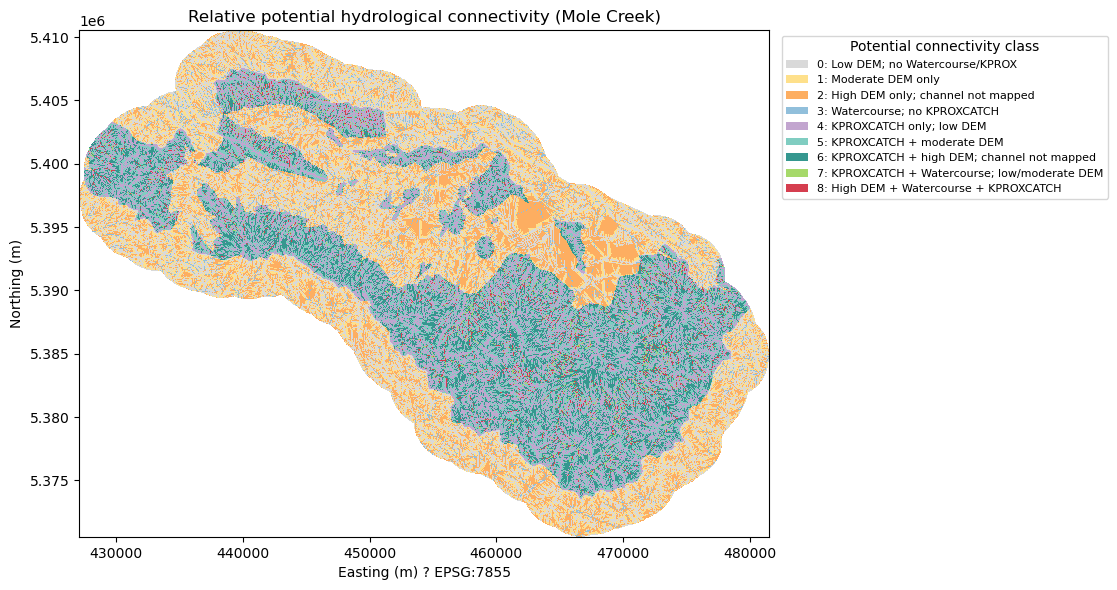

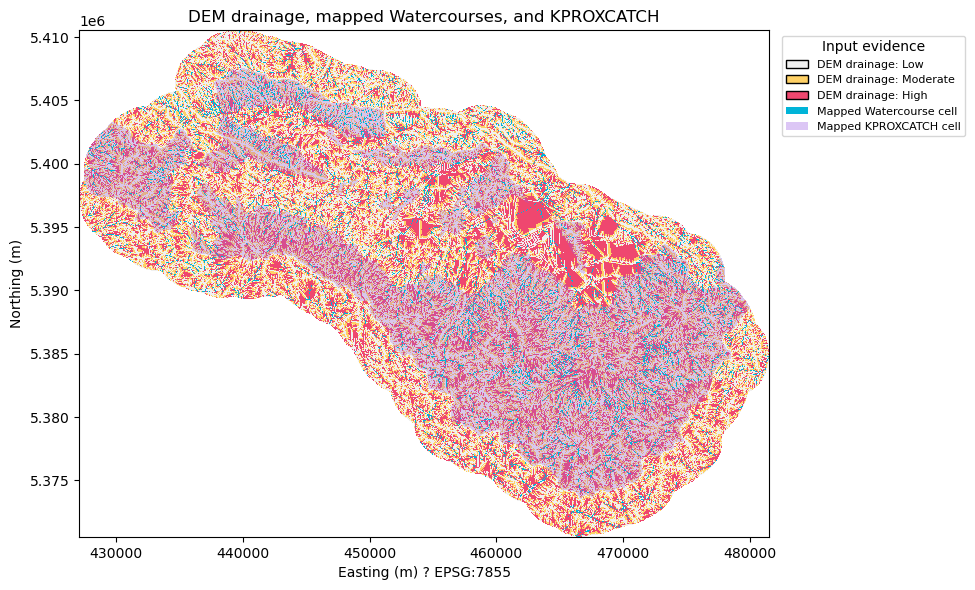

In [6]:
flow_height, flow_width = flow_masked.shape
left, bottom, right, top = rasterio.transform.array_bounds(
    flow_height, flow_width, flow_transform
)
raster_extent = (left, right, bottom, top)

final_labels = {
    0: "Low DEM; no Watercourse/KPROX",
    1: "Moderate DEM only",
    2: "High DEM only; channel not mapped",
    3: "Watercourse; no KPROXCATCH",
    4: "KPROXCATCH only; low DEM",
    5: "KPROXCATCH + moderate DEM",
    6: "KPROXCATCH + high DEM; channel not mapped",
    7: "KPROXCATCH + Watercourse; low/moderate DEM",
    8: "High DEM + Watercourse + KPROXCATCH",
}
final_colors = [
    "#d9d9d9", "#fee08b", "#fdae61", "#91bfdb", "#c2a5cf",
    "#80cdc1", "#35978f", "#a6d96a", "#d53e4f",
]
final_cmap = ListedColormap(final_colors)
final_display = np.ma.masked_equal(final_connectivity, 255)

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(
    final_display,
    extent=raster_extent,
    origin="upper",
    cmap=final_cmap,
    vmin=-0.5,
    vmax=8.5,
    interpolation="nearest",
)
final_handles = [
    Patch(facecolor=final_colors[code], label=f"{code}: {label}")
    for code, label in final_labels.items()
]
ax.legend(handles=final_handles, title="Potential connectivity class", loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title("Relative potential hydrological connectivity (Mole Creek)")
ax.set_xlabel(f"Easting (m) ? {flow_crs}")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(right=0.70)
plt.show()

# Combined view of the input evidence, not a numerical combination.
flow_colors = ["#f0f0f0", "#ffd166", "#ef476f"]
flow_display = np.ma.masked_equal(dem_drainage_class, 255)
kprox_display = np.ma.masked_where(kproxcatch_presence != 1, kproxcatch_presence)
watercourse_display = np.ma.masked_where(watercourse_presence != 1, watercourse_presence)

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(
    flow_display,
    extent=raster_extent,
    origin="upper",
    cmap=ListedColormap(flow_colors),
    vmin=1,
    vmax=3,
    interpolation="nearest",
)
ax.imshow(
    kprox_display,
    extent=raster_extent,
    origin="upper",
    cmap=ListedColormap(["#9b5de5"]),
    alpha=0.28,
    interpolation="nearest",
)
ax.imshow(
    watercourse_display,
    extent=raster_extent,
    origin="upper",
    cmap=ListedColormap(["#00b4d8"]),
    interpolation="nearest",
)
input_handles = [
    Patch(facecolor=flow_colors[0], edgecolor="black", label="DEM drainage: Low"),
    Patch(facecolor=flow_colors[1], edgecolor="black", label="DEM drainage: Moderate"),
    Patch(facecolor=flow_colors[2], edgecolor="black", label="DEM drainage: High"),
    Patch(facecolor="#00b4d8", label="Mapped Watercourse cell"),
    Patch(facecolor="#9b5de5", alpha=0.35, label="Mapped KPROXCATCH cell"),
]
ax.legend(handles=input_handles, title="Input evidence", loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title("DEM drainage, mapped Watercourses, and KPROXCATCH")
ax.set_xlabel(f"Easting (m) ? {flow_crs}")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(right=0.70)
plt.show()


## Interpretation and limits

The map shows **relative potential for surface water to be concentrated and connected to mapped karst catchments**. High flow accumulation without a Watercourse remains potential drainage (classes 2 or 6); a Watercourse is retained even when DEM accumulation is Low (classes 3 or 7). Class 8 is the strongest combined evidence under the table above.

The D8 accumulation raster is based on the existing depression-filled DEM and indicates relative upslope cell contribution. It is not measured flow, discharge, or groundwater movement. Watercourse presence is binary evidence of mapped drainage, not flow magnitude. `KPROXCATCH` indicates mapped proximal catchment presence; it does not establish an underground flow path for every pixel.
